# PHASE 5B: PyTorch Deep Learning (LSTM + CNN-LSTM)

## Objective
Upgrade sequence modeling to follow the comprehensive plan and Source C principles:
- engine-safe windowing,
- leakage-safe scaling,
- robust training controls,
- correct regression metrics and visual diagnostics.

## Input
- `../data/processed/train_cleaned.csv`


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

TRAIN_PATH = Path('../data/processed/train_cleaned.csv')
TEST_PATH = Path('../data/processed/valid_cleaned.csv')
ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_LENGTH = 30
SHIFT = 1
EARLY_RUL = 125
BATCH_SIZE = 128
EPOCHS = 40
PATIENCE = 8
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})

print(f'Using device: {DEVICE}')
print(f'Window length: {WINDOW_LENGTH}, shift: {SHIFT}, early_rul: {EARLY_RUL}')

Using device: cpu
Window length: 30, shift: 1, early_rul: 125


### Split and scaling rationale
- `train_cleaned.csv` is used fully as training source.
- `valid_cleaned.csv` is used as test source.
- Features are scaled with train-fitted statistics and then transformed onto test.
- 3D data is created via per-engine sliding windows `(samples, window_length, features)`.

In [2]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

required_cols = {'unit_number', 'time_cycles', 'RUL'}
missing_train = required_cols - set(df_train.columns)
missing_test = required_cols - set(df_test.columns)
if missing_train:
    raise ValueError(f'Train file missing required columns: {missing_train}')
if missing_test:
    raise ValueError(f'Test file missing required columns: {missing_test}')

# Keep engine timeline integrity
df_train = df_train.sort_values(['unit_number', 'time_cycles']).reset_index(drop=True)
df_test = df_test.sort_values(['unit_number', 'time_cycles']).reset_index(drop=True)

df_train['RUL_clipped'] = df_train['RUL'].clip(upper=EARLY_RUL)
df_test['RUL_clipped'] = df_test['RUL'].clip(upper=EARLY_RUL)

sensor_cols = [c for c in df_train.columns if c.startswith('s_')]
setting_cols = [c for c in df_train.columns if c.startswith('setting_')]
feature_cols = setting_cols + sensor_cols

tr_df = df_train.copy()
te_df = df_test.copy()

# Leakage-safe scaling: fit on train only, apply to test
scaler = StandardScaler()
tr_df[feature_cols] = scaler.fit_transform(tr_df[feature_cols])
te_df[feature_cols] = scaler.transform(te_df[feature_cols])

print(f'Train rows: {tr_df.shape[0]} (from train_cleaned.csv)')
print(f'Test  rows: {te_df.shape[0]} (from valid_cleaned.csv)')
print(f'Features: {len(feature_cols)}')

Train rows: 20631 (from train_cleaned.csv)
Test  rows: 13096 (from valid_cleaned.csv)
Features: 17


### Split and scaling rationale
- Uses full `train_cleaned.csv` as train source and `valid_cleaned.csv` as test source.
- Scaler is fit **only** on train rows, then applied to test.
- **FIX:** An engine-level 80/20 split is applied to `tr_df` to produce a held-out `val` set.
  Early stopping uses `val_loader` — the test set is never seen during training.


In [3]:
def build_sequences(df_split, feature_cols, window_length=30, shift=1):
    xs, ys = [], []
    for _, g in df_split.groupby('unit_number'):
        g = g.sort_values('time_cycles')
        X = g[feature_cols].to_numpy(dtype=np.float32)
        y = g['RUL_clipped'].to_numpy(dtype=np.float32)

        if len(g) < window_length:
            continue

        n_batches = int(np.floor((len(g) - window_length) / shift)) + 1
        for b in range(n_batches):
            s = b * shift
            e = s + window_length
            xs.append(X[s:e])
            ys.append(y[e - 1])

    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


# FIX: Engine-level 80/20 split from training data for validation.
# Early stopping will use val_loader, keeping test set strictly held-out.
all_engines = tr_df['unit_number'].unique()
rng = np.random.default_rng(42)
val_engine_ids = rng.choice(all_engines, size=max(1, int(len(all_engines) * 0.2)), replace=False)
train_engine_ids = np.setdiff1d(all_engines, val_engine_ids)

tr_df_train = tr_df[tr_df['unit_number'].isin(train_engine_ids)]
tr_df_val   = tr_df[tr_df['unit_number'].isin(val_engine_ids)]

X_train, y_train = build_sequences(tr_df_train, feature_cols, WINDOW_LENGTH, SHIFT)
X_val,   y_val   = build_sequences(tr_df_val,   feature_cols, WINDOW_LENGTH, SHIFT)
X_test,  y_test  = build_sequences(te_df,        feature_cols, WINDOW_LENGTH, SHIFT)

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError('A split has zero sequences. Reduce window length or check data files.')

print('3D sequence shapes:')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'  X_test : {X_test.shape}  y_test : {y_test.shape}')

3D sequence shapes:
  X_train: (14070, 30, 17)  y_train: (14070,)
  X_val  : (3661, 30, 17)  y_val  : (3661,)
  X_test : (10196, 30, 17)  y_test : (10196,)


### Sequence construction
- Implements Source C style sliding windows per engine.
- Target for each window is the window-end clipped RUL.


In [4]:
class CMAPSSDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


train_loader = DataLoader(CMAPSSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CMAPSSDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CMAPSSDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders ready')

DataLoaders ready


### Data loader policy
- Training uses shuffled batches.
- `val_loader` is used as the early-stopping signal during training (held-out train engines).
- `test_loader` is strictly reserved for final evaluation only.


In [5]:
class RULLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class RULCNNLSTMHybrid(nn.Module):
    """
    Hybrid CNN-LSTM architecture for RUL prediction.

    Stage 1 — CNN feature extractor:
        Two stacked Conv1d layers slide a kernel across the time window to detect
        local sensor patterns (e.g. sharp spikes, gradual drift within a short span).
        Each timestep is transformed from raw sensor space (input_dim) into a richer
        local-feature space (num_filters * 2), preserving the full sequence length.

    Stage 2 — LSTM temporal modelling:
        The LSTM receives the sequence of CNN-extracted feature vectors and learns
        long-term temporal dependencies that indicate progressive engine degradation
        across the window. Only the final hidden state is used for regression.

    Data flow:
        (batch, time, input_dim)
        -> permute -> (batch, input_dim, time)          # Conv1d expects (N, C, L)
        -> CNN      -> (batch, num_filters*2, time)     # local pattern features
        -> permute -> (batch, time, num_filters*2)      # LSTM expects (N, L, H_in)
        -> LSTM     -> (batch, time, hidden_dim)        # temporal context
        -> last step -> (batch, hidden_dim)             # degradation state
        -> head     -> (batch,)                         # predicted RUL
    """
    def __init__(self, input_dim, num_filters=64, kernel_size=3,
                 num_lstm_layers=2, hidden_dim=64, dropout=0.2):
        super().__init__()

        # --- Stage 1: CNN feature extractor ---
        # same-padding (padding = kernel_size // 2) preserves sequence length so
        # the LSTM receives one feature vector per original timestep.
        self.cnn_extractor = nn.Sequential(
            # Layer 1: detect fine-grained local sensor patterns
            nn.Conv1d(input_dim, num_filters, kernel_size,
                      padding=kernel_size // 2),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            # Layer 2: compose low-level patterns into richer local representations
            nn.Conv1d(num_filters, num_filters * 2, kernel_size,
                      padding=kernel_size // 2),
            nn.BatchNorm1d(num_filters * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Stage 2: LSTM temporal modeller ---
        # Receives the CNN feature sequence and captures how local patterns
        # evolve over time — the signature of cumulative engine degradation.
        self.lstm_temporal = nn.LSTM(
            input_size=num_filters * 2,   # matches CNN output channels
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout,
        )

        # --- Regression head ---
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (batch, time, input_dim)

        # Stage 1: extract local patterns with CNN
        x = x.permute(0, 2, 1)              # (batch, input_dim, time)
        x = self.cnn_extractor(x)           # (batch, num_filters*2, time)
        x = x.permute(0, 2, 1)             # (batch, time, num_filters*2)

        # Stage 2: model temporal degradation dependencies with LSTM
        lstm_out, _ = self.lstm_temporal(x) # (batch, time, hidden_dim)
        last_step = lstm_out[:, -1, :]      # (batch, hidden_dim) — final degradation state

        return self.head(last_step).squeeze(-1)  # (batch,)


print('Model classes ready')

Model classes ready


### Architecture: CNN-LSTM hybrid
- **Stage 1 — CNN feature extractor**: two stacked `Conv1d` layers with same-padding
  (`padding = kernel_size // 2`) slide across the time window to detect local sensor
  patterns (e.g. abrupt spikes, short-span drift). Sequence length is fully preserved
  so the LSTM receives one feature vector per original timestep.
- **Stage 2 — LSTM temporal modeller**: processes the CNN-extracted feature sequence
  to capture long-term temporal dependencies indicative of progressive engine degradation.
  Only the final hidden state is passed to the regression head.
- `BatchNorm1d` after each conv layer stabilises training; `Dropout` is applied in
  both the CNN block and between LSTM layers.


In [6]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)))


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    losses = []
    preds_all, true_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            pred = model(xb)
            loss = criterion(pred, yb)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        true_all.append(yb.detach().cpu().numpy())

    y_pred = np.concatenate(preds_all)
    y_true = np.concatenate(true_all)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return np.mean(losses), rmse, y_true, y_pred


def train_with_early_stopping(model, model_name, train_loader, eval_loader, epochs=40, patience=8):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

    history = {'train_loss': [], 'eval_loss': [], 'train_rmse': [], 'eval_rmse': []}
    best_eval_rmse = np.inf
    best_state = None
    wait = 0

    for ep in range(1, epochs + 1):
        tr_loss, tr_rmse, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        ev_loss, ev_rmse, _, _ = run_epoch(model, eval_loader, criterion, optimizer=None)

        history['train_loss'].append(tr_loss)
        history['eval_loss'].append(ev_loss)
        history['train_rmse'].append(tr_rmse)
        history['eval_rmse'].append(ev_rmse)

        if ev_rmse < best_eval_rmse:
            best_eval_rmse = ev_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if ep % 5 == 0 or ep == 1:
            print(f"{model_name} | epoch {ep:02d} | train_rmse {tr_rmse:.4f} | val_rmse {ev_rmse:.4f}")

        if wait >= patience:
            print(f"{model_name} early stopping at epoch {ep}")
            break

    model.load_state_dict(best_state)
    return model, history


In [7]:
lstm_model     = RULLSTM(input_dim=len(feature_cols))
cnn_lstm_model = RULCNNLSTMHybrid(input_dim=len(feature_cols))

# FIX: Pass val_loader (not test_loader) as the early-stopping signal.
lstm_model,     lstm_hist     = train_with_early_stopping(lstm_model,     'LSTM',     train_loader, val_loader, EPOCHS, PATIENCE)
cnn_lstm_model, cnn_lstm_hist = train_with_early_stopping(cnn_lstm_model, 'CNN-LSTM', train_loader, val_loader, EPOCHS, PATIENCE)


LSTM | epoch 01 | train_rmse 70.9843 | val_rmse 41.3834
LSTM | epoch 05 | train_rmse 14.8409 | val_rmse 14.5305
LSTM | epoch 10 | train_rmse 13.6266 | val_rmse 15.0476
LSTM early stopping at epoch 14
CNN-LSTM | epoch 01 | train_rmse 84.5105 | val_rmse 77.5985
CNN-LSTM | epoch 05 | train_rmse 18.2243 | val_rmse 15.9910
CNN-LSTM | epoch 10 | train_rmse 14.6131 | val_rmse 16.1161
CNN-LSTM early stopping at epoch 14


### Training controls
- Uses gradient clipping, weight decay, and early stopping.
- Early stopping monitors `val_rmse` (held-out train engines) — test set is never touched during training.
- Tracks both loss and RMSE curves to align optimization with regression performance.


In [8]:
def evaluate_model(model, loader, name):
    criterion = nn.MSELoss()
    _, _, y_true, y_pred = run_epoch(model, loader, criterion, optimizer=None)
    metrics = {
        'model': name,
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'nasa': float(nasa_score(y_true, y_pred)),
    }
    return metrics, y_true, y_pred

print('evaluate_model() defined')


evaluate_model() defined


In [9]:
lstm_metrics, y_true_lstm, y_pred_lstm = evaluate_model(lstm_model, test_loader, 'LSTM')
print('LSTM  | rmse:', round(lstm_metrics['rmse'], 4), '| mae:', round(lstm_metrics['mae'], 4),
      '| r2:', round(lstm_metrics['r2'], 4), '| nasa:', round(lstm_metrics['nasa'], 2))


LSTM  | rmse: 14.0086 | mae: 9.8975 | r2: 0.7779 | nasa: 50105.24


In [10]:
cnn_lstm_metrics, y_true_cnn_lstm, y_pred_cnn_lstm = evaluate_model(cnn_lstm_model, test_loader, 'CNN-LSTM')
print('CNN-LSTM | rmse:', round(cnn_lstm_metrics['rmse'], 4), '| mae:', round(cnn_lstm_metrics['mae'], 4),
      '| r2:', round(cnn_lstm_metrics['r2'], 4), '| nasa:', round(cnn_lstm_metrics['nasa'], 2))


CNN-LSTM | rmse: 15.5386 | mae: 11.5794 | r2: 0.7268 | nasa: 52659.03


In [11]:
metrics_df = pd.DataFrame([lstm_metrics, cnn_lstm_metrics]).sort_values(['rmse', 'nasa']).reset_index(drop=True)
print('Test metrics:')
display(metrics_df)

# Save model artifacts
torch.save(lstm_model.state_dict(),     ARTIFACTS_DIR / 'lstm_model.pth')
torch.save(cnn_lstm_model.state_dict(), ARTIFACTS_DIR / 'cnn_lstm_model.pth')


Test metrics:


,model,rmse,mae,r2,nasa
0,LSTM,14.008567,9.897548,0.777922,50105.242188
1,CNN-LSTM,15.538557,11.579442,0.726764,52659.027344


### Test metric interpretation
- Reported metrics match plan requirements: RMSE, MAE, R², NASA score.
- These metrics are now unbiased — the test set was never used during training or model selection.
- Artifact files are persisted for downstream ensemble/selection.


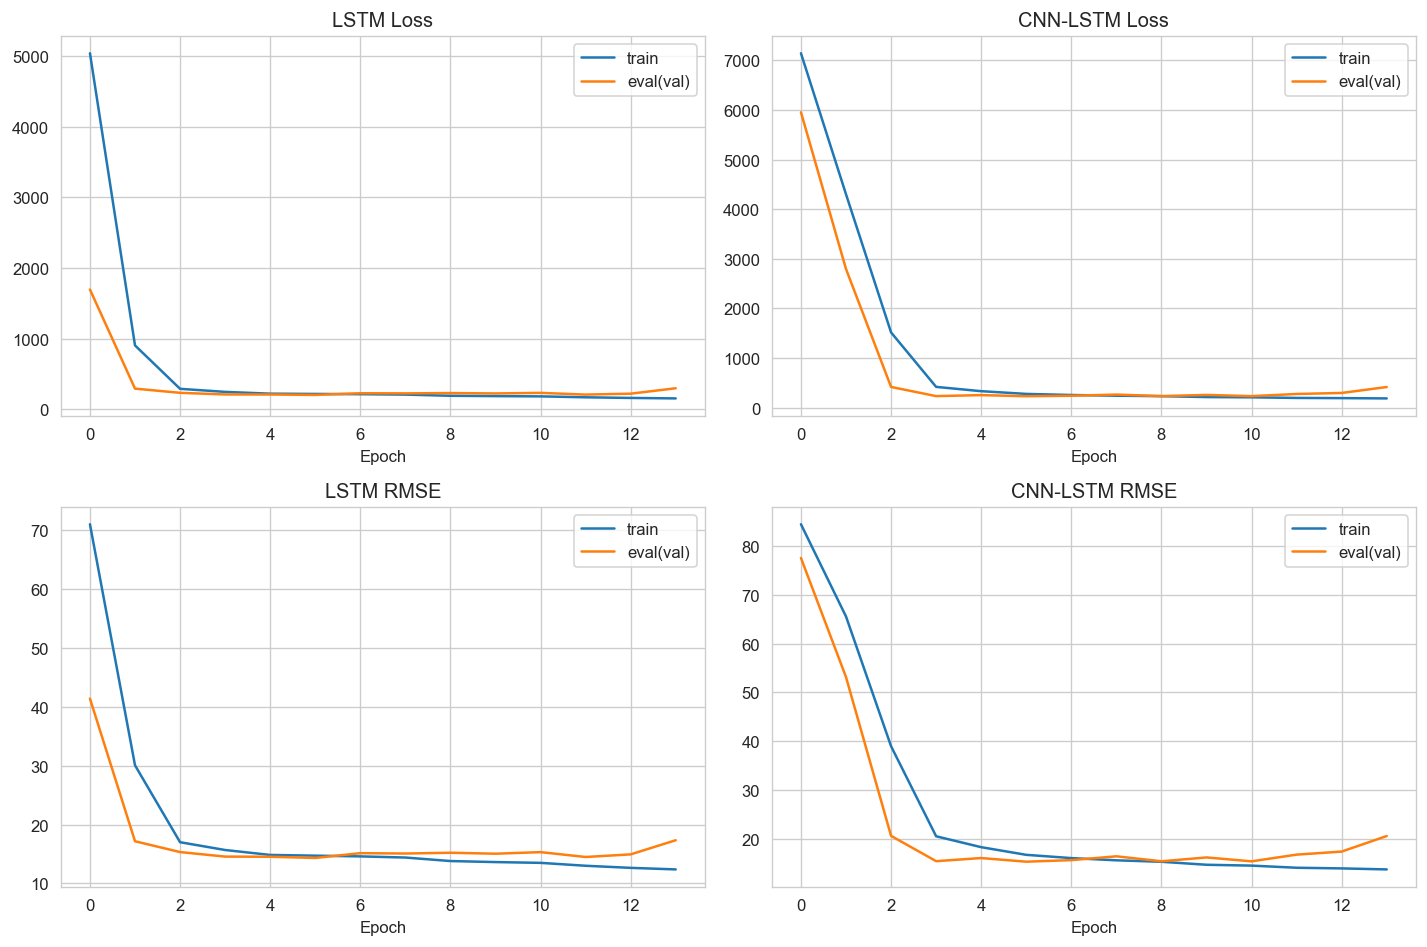

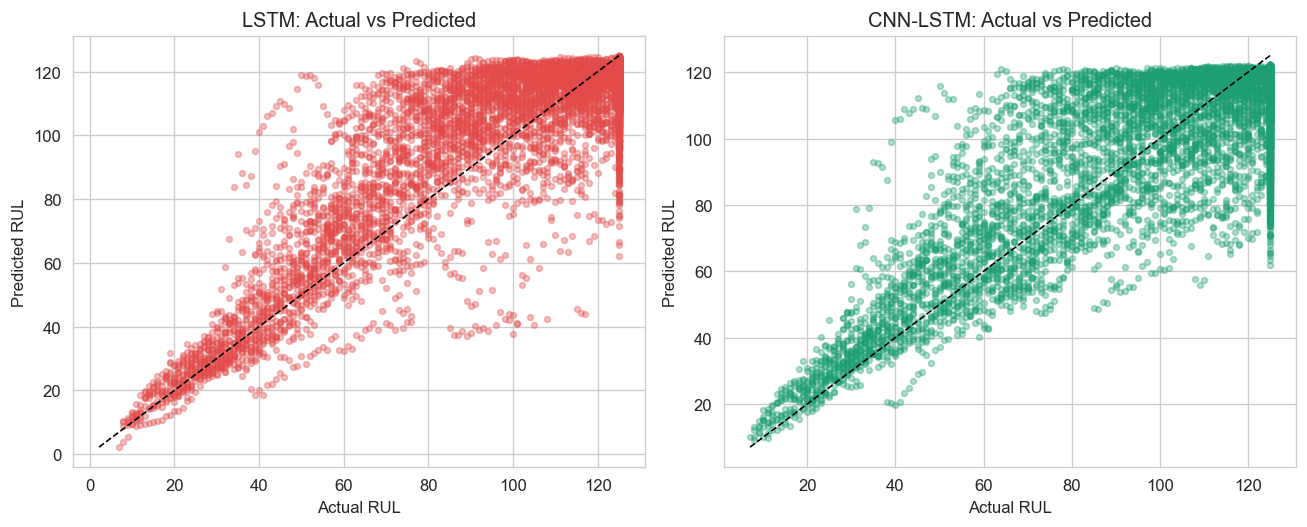

In [12]:
# Learning curves — 2 models x (Loss + RMSE)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (hist, name) in enumerate([
    (lstm_hist,     'LSTM'),
    (cnn_lstm_hist, 'CNN-LSTM'),
]):
    axes[0, col].plot(hist['train_loss'], label='train')
    axes[0, col].plot(hist['eval_loss'],  label='eval(val)')
    axes[0, col].set_title(f'{name} Loss')
    axes[0, col].legend()

    axes[1, col].plot(hist['train_rmse'], label='train')
    axes[1, col].plot(hist['eval_rmse'],  label='eval(val)')
    axes[1, col].set_title(f'{name} RMSE')
    axes[1, col].legend()

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

# Prediction diagnostics — actual vs predicted scatter for both models
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for i, (y_true, y_pred, name, color) in enumerate([
    (y_true_lstm,     y_pred_lstm,     'LSTM',     '#E24B4A'),
    (y_true_cnn_lstm, y_pred_cnn_lstm, 'CNN-LSTM', '#1D9E75'),
]):
    ax[i].scatter(y_true, y_pred, s=12, alpha=0.35, color=color)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax[i].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    ax[i].set_title(f'{name}: Actual vs Predicted')
    ax[i].set_xlabel('Actual RUL')
    ax[i].set_ylabel('Predicted RUL')

plt.tight_layout()
plt.show()


As the actual RUL increases beyond 60 units, the scatter plot shows significantly more variance and "noise." The data points become more dispersed, and there is a noticeable horizontal plateau where many predictions cluster around the 120-unit mark, regardless of the actual RUL being higher. This indicates that the model struggle to differentiate between various stages of an asset's early life and likely employs a "clipping" mechanism or an upper bound on its predictions. Additionally, there is a vertical column of points at the far right of the graph, showing that for the highest actual RUL values, the model's predictions vary wildly from approximately 80 to 125.

### Visualization policy
- Shows convergence behavior (loss + RMSE) and prediction fit (actual vs predicted).
- Enables direct comparison of LSTM and CNN-LSTM generalization quality.


## Transition to next stage
This notebook outputs:
- Trained `lstm_model.pth` and `cnn_lstm_model.pth` artifacts.
- Reproducible DL metric table for model selection and ensemble integration.
